<a href="https://colab.research.google.com/github/caoyang0428-art/ML-Assignment/blob/main/Haiteng_Assignment_Yang.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Haiteng Engineering: Quality Control Analysis

I understand that participants are encouraged to use LLMs like ChatGPT as a helpful resource to better understand the assignment. You can upload the case file and ask GPT questions to clarify the context, analyze the data, or explore different aspects of the case study. However, please note that LLMs should not be used to generate any code for this assignment. Focus on leveraging LLMs to deepen your understanding rather than as a shortcut for solving coding tasks.

# Student Name: Yang Cao

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Part 1: Vendor AOI Analysis

In [ ]:
# Given confusion matrix data
vendor_matrix = np.array([
    [3603, 1152],  # Conforming
    [87, 198]      # Non-conforming
])

In [ ]:
# TODO: Calculate key metrics
def calculate_performance_metrics(confusion_matrix):
    """
    Calculate inspection accuracy, scrap rate, and escape rate

    Parameters:
    confusion_matrix: 2x2 numpy array [[TN, FP], [FN, TP]]

    Returns:
    dict with calculated metrics
    """
    TN = confusion_matrix[0,0]
    FP = confusion_matrix[0,1]
    FN = confusion_matrix[1,0]
    TP = confusion_matrix[1,1]
    accuracy = (TN + TP)/(TN + FP + FN + TP)
    scrap_rate = FP / (FP + TN)
    escape_rate = FN / (FN + TP)
    return {
        'accuracy': accuracy,
        'scrap_rate': scrap_rate,
        'escape_rate': escape_rate,
        'TN': TN,
        'FP': FP,
        'FN': FN,
        'TP': TP
    }
    # Hint: TN = confusion_matrix[0,0], FP = confusion_matrix[0,1], etc.

In [ ]:
metrics = calculate_performance_metrics(vendor_matrix)
print(f"Accuracy:    {metrics['accuracy']:.1%}")
print(f"Scrap Rate:  {metrics['scrap_rate']:.1%}")
print(f"Escape Rate: {metrics['escape_rate']:.1%}")

Accuracy:    75.4%
Scrap Rate:  24.2%
Escape Rate: 30.5%


In [ ]:
# TODO: Calculate annual costs
def calculate_annual_costs(confusion_matrix, annual_production=50000,
                         unit_cost=2280, return_cost=3200,final_inspection_accuracy=0.99, maintenance=125000):
    """
    Calculate annual costs from confusion matrix

    Returns:
    dict with costs breakdown
    """
    metrics = calculate_performance_metrics(confusion_matrix)
    scrap_rate  = metrics['scrap_rate']
    escape_rate = metrics['escape_rate']

    scrap_cost  = scrap_rate * annual_production * unit_cost
    return_cost_total = escape_rate * (1 - final_inspection_accuracy) * annual_production * return_cost
    maintenance_cost = maintenance

    total_cost= scrap_cost + return_cost_total +  maintenance_cost

    return {
        'scrap_cost': scrap_cost,
        'return_cost': return_cost_total,
        'maintenance_cost': maintenance_cost,
        'total_cost': total_cost
    }

In [ ]:
costs = calculate_annual_costs(vendor_matrix)
print("Scrap cost:", round(costs['scrap_cost']))
print("Return cost:", round(costs['return_cost']))
print("Maintenance cost:", round(costs['maintenance_cost']))
print("Total cost:", round(costs['total_cost']))

Scrap cost: 27618927
Return cost: 488421
Maintenance cost: 125000
Total cost: 28232348


## Part 2: Custom Solution Analysis

In [ ]:
# Setup Quality Inspection System
# I run on Google Colab due to M1 Mac compatibility issues with OpenCV DNN :(
RESOURCE_PATH = '/content/resources'  # TODO: Update this path
from resources.VQI import QualityInspectionSystem
QIS = QualityInspectionSystem(RESOURCE_PATH)

In [ ]:
# First, let's test the inspection system on a single impeller
test_impeller = "def_front_cast_def_0_7"
inspection_result = QIS.classify_part(test_impeller)

if(inspection_result is not None):
    print("\nVisual Quality Inspection Results:")
    print(f"  Part ID: {test_impeller}")
    print(f"  Conforming probability:     {inspection_result[0,0]:.1%}")
    print(f"  Non-conforming probability: {inspection_result[0,1]:.1%}")


Visual Quality Inspection Results:
  Part ID: def_front_cast_def_0_7
  Conforming probability:     9.9%
  Non-conforming probability: 90.1%


In [ ]:
# Now, let's inspect all test impellers
part_names, actual_status = QIS.load_dataset()
probabilities = np.zeros((len(part_names), 2))  # Store inspection decisions

# TODO: Perform inspection on all parts
def run_inspection():
    """
    Run quality inspection on all test parts

    Returns:
    probabilities: numpy array (n_samples, 2) with [conforming, non-conforming] probabilities
    """
    probabilities = np.zeros((len(part_names), 2))

    for i, name in enumerate(part_names):
        result = QIS.classify_part(name)
        probabilities[i] = result[0]

    # Your code here
    # Hint 1: Loop through part_names
    # Hint 2: Use QIS.classify_part() for each part
    # Hint 3: Store results in probabilities array

    return probabilities

# Run inspection
probabilities = run_inspection()
print(f"\nInspection complete:")
print(f"Total parts inspected: {len(part_names)}")
print(f"First 5 inspection results:\n{probabilities[:5]}")


Inspection complete:
Total parts inspected: 715
First 5 inspection results:
[[0.98306721 0.01693279]
 [0.93733203 0.06266797]
 [0.92758423 0.07241573]
 [0.97582769 0.02417236]
 [0.87045449 0.12954554]]


In [ ]:
def create_confusion_matrix(probabilities, actual_status):
    """
    Create confusion matrix using 0.5 threshold

    Parameters:
    probabilities: numpy array (n_samples, 2) with [conforming, non-conforming] probabilities
    actual_status: numpy array (n_samples,) with True for non-conforming

    Returns:
    confusion_matrix: 2x2 numpy array [[TN, FP], [FN, TP]]
    """

    non_conforming_probs = probabilities[:, 1]
    predicted = non_conforming_probs > 0.5
    predicted = predicted.astype(int)

    TN = np.sum((actual_status == 0) & (predicted == 0))
    FP = np.sum((actual_status == 0) & (predicted == 1))
    FN = np.sum((actual_status == 1) & (predicted == 0))
    TP = np.sum((actual_status == 1) & (predicted == 1))

    return np.array([[TN, FP], [FN, TP]])

    # Hint: Classify as non-conforming if non-conforming probability > 0.5

In [ ]:
custom_matrix = create_confusion_matrix(probabilities, actual_status)
print("Custom confusion matrix:")
print(custom_matrix)

Custom confusion matrix:
[[253   9]
 [  4 449]]


In [ ]:
# Calculate performance
custom_metrics = calculate_performance_metrics(custom_matrix)
print(f"Accuracy:    {custom_metrics['accuracy']:.1%}")
print(f"Scrap Rate:  {custom_metrics['scrap_rate']:.1%}")
print(f"Escape Rate: {custom_metrics['escape_rate']:.1%}")
print()

# Calculate total cost
custom_costs = calculate_annual_costs(custom_matrix, maintenance=250000)
print("Scrap cost:", round(custom_costs['scrap_cost']))
print("Return cost:", round(custom_costs['return_cost']))
print("Maintenance cost:", round(custom_costs['maintenance_cost']))
print("Total cost:", round(custom_costs['total_cost']))

Accuracy:    98.2%
Scrap Rate:  3.4%
Escape Rate: 0.9%

Scrap cost: 3916031
Return cost: 14128
Maintenance cost: 250000
Total cost: 4180159


In [ ]:
# Comparison and Payback Analysis
vendor_total = 28232348
custom_total = custom_costs['total_cost']

annual_savings = vendor_total - custom_total
print(f"Annual savings (Custom vs Vendor): ¥{round(annual_savings):,}")

investment_custom = 2200000
investment_vendor = 1200000
incremental_investment = investment_custom - investment_vendor
print(f"Incremental investment (Custom over Vendor): ¥{incremental_investment:,}")

payback_months = (incremental_investment / annual_savings) * 12
print(f"Incremental Payback Period: {payback_months:.2f} months")

roi = (annual_savings / investment_custom) * 100
print(f"ROI (Year 1): {roi:.0f}%")

print(f"\n1-year payback achieved? {'YES' if payback_months <= 12 else 'NO'}")

Annual savings (Custom vs Vendor): ¥24,052,189
Incremental investment (Custom over Vendor): ¥1,000,000
Incremental Payback Period: 0.50 months
ROI (Year 1): 1093%

1-year payback achieved? YES


In [ ]:
def create_confusion_matrix(probabilities, actual_status, threshold=0.5):
    """
    Create confusion matrix using given threshold
    """
    non_conforming_probs = probabilities[:, 1]
    predicted = non_conforming_probs > threshold
    predicted = predicted.astype(int)

    TN = np.sum((actual_status == 0) & (predicted == 0))
    FP = np.sum((actual_status == 0) & (predicted == 1))
    FN = np.sum((actual_status == 1) & (predicted == 0))
    TP = np.sum((actual_status == 1) & (predicted == 1))

    return np.array([[TN, FP], [FN, TP]])

Optimal threshold: 0.90
Minimum annual cost: ¥546,689
Optimal threshold: 0.90
Minimum annual cost: ¥546,689


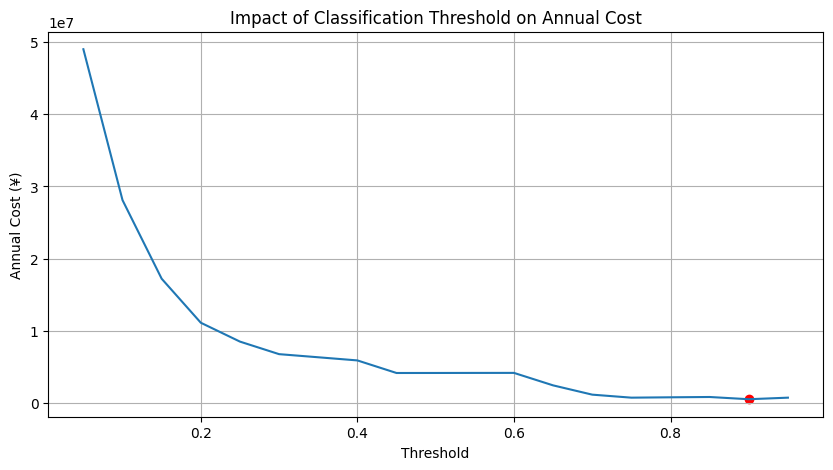

In [ ]:
thresholds = np.arange(0.05, 0.96, 0.05)
costs = []

for t in thresholds:
    cm = create_confusion_matrix(probabilities, actual_status, threshold=t)
    cost_dict = calculate_annual_costs(cm, maintenance=250000)
    costs.append(cost_dict['total_cost'])

best_idx = np.argmin(costs)
best_threshold = thresholds[best_idx]
best_cost = costs[best_idx]

print(f"Optimal threshold: {best_threshold:.2f}")
print(f"Minimum annual cost: ¥{best_cost:,.0f}")

QIS.create_visualization(thresholds, costs)

In [ ]:
# Recalculate with optimal threshold
optimal_total = best_cost     # ¥546,689
annual_savings_optimal = vendor_total - optimal_total

payback_months_optimal = (incremental_investment / annual_savings_optimal) * 12
roi_optimal = (annual_savings_optimal / investment_custom) * 100

print(f"At optimal threshold 0.90:")
print(f"  Annual savings vs vendor: ¥{round(annual_savings_optimal):,}")
print(f"  Payback period: {payback_months_optimal:.2f} months")
print(f"  ROI Year 1: {roi_optimal:.0f}%")

At optimal threshold 0.90:
  Annual savings vs vendor: ¥27,685,659
  Payback period: 0.43 months
  ROI Year 1: 1258%


## Part 3: Strategic Analysis

Example, don't include this in your notebook but create a separate file.

---

### MEMORANDUM

**TO:** Zhang Yuelan, COO, Haiteng Engineering  
**FROM:** [Student Name]  
**DATE:** [Current Date]  
**SUBJECT:** Quality Control System Recommendation  

#### EXECUTIVE SUMMARY
[One paragraph summarizing your recommendation and its primary justification]

#### ANALYSIS

[Compare inspection performance metrics, quality standards compliance, and financial impact, total cost, etc.]

#### RECOMMENDATION
[Clear recommendation with justification covering performance metrics, quality assurance, and strategic fit]

[Justified recommended action]

#### IMPLEMENTATION PLAN

[Timeline, resources, risk management, and success metrics]

[End with a clear call to action]

---